In [1]:
from os.path import abspath
from PIL import Image
from sys import path
path.insert(0, abspath("../.."))  # Repository directory relative to this file.
from MISalign.model.mis_file import load_mis
absolute_fp = "/Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/set_b2.mis"
mis_project = load_mis( absolute_fp )
from MISalign.model.relation import Relation

In [2]:
mis_project = load_mis("/Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/set_b2_clean.mis")
relations=mis_project.get_rels()
relations_rect=mis_project.get_rels('r')
relations_pts=mis_project.get_rels('p')
image_paths=mis_project.get_image_paths()

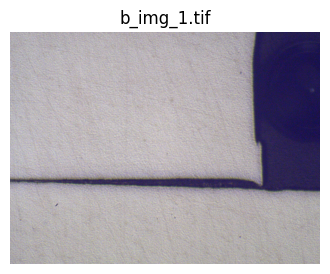

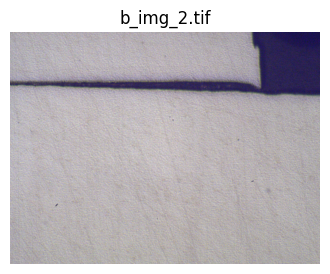

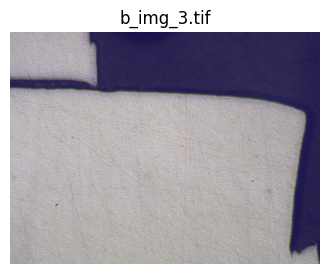

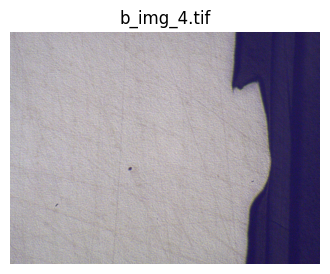

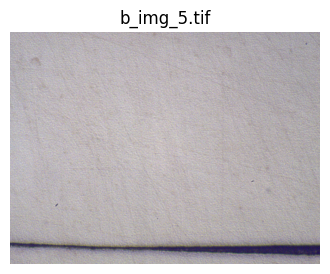

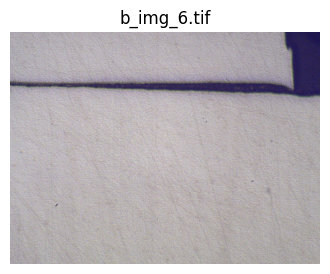

In [3]:
#prv1: Open images of first relation in set_b2.mis file and display them. Print out the relation between the images.
from PIL import Image
import matplotlib.pyplot as plt

image_paths = mis_project.get_image_paths()

# open each image and display it
for name, path in image_paths.items():
    img = Image.open(path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(name)
    plt.axis('off')
    plt.show()

In [4]:
for i,rel in enumerate(relations):
    print(i,rel)
    print(relations_rect[i])
    print(relations_pts[i])
    print(image_paths[rel[0]],image_paths[rel[1]])
    print()

0 ('b_img_1.tif', 'b_img_2.tif')
[('b_img_1.tif', 'b_img_2.tif'), (-20, -507)]
[('b_img_1.tif', 'b_img_2.tif'), [[[1299, 589], [1276, 85]], [[1305, 806], [1287, 296]]]]
/Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/b_img_1.tif /Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/b_img_2.tif

1 ('b_img_2.tif', 'b_img_3.tif')
[('b_img_2.tif', 'b_img_3.tif'), (-568, -5)]
[('b_img_2.tif', 'b_img_3.tif'), [[[1293, 298], [438, 291]], [[1282, 87], [426, 74]], [[1339, 835], [1344, 838]]]]
/Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/b_img_2.tif /Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/b_img_3.tif

2 ('b_img_3.tif', 'b_img_4.tif')
[('b_img_3.tif', 'b_img_4.tif'), (-308, -843)]
[('b_img_3.tif', 'b_img_4.tif'), [[[1584, 1120], [1276, 279]], [[1476, 1148], [1168, 302]]]]
/Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/b_img_3.tif /Users/katrin

In [5]:
#prv2: copy/modify/build from existing `interactive_manual.py` code to show images next to one another with related points marked and lines drawn between them.

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from MISalign.model.mis_file import load_mis

#1) load MIS file and point relations 
mis_fp = "/Users/katrinachou/Documents/GitHub/MISalign/MISalign-copy/example/data/set_b/set_b2_clean.mis"
mis   = load_mis(mis_fp)

pt_rels = mis.get_rels('p')




In [6]:
# 2) remove any duplicates 
seen = set()
unique_pt_rels = []
for (A, B), pts in pt_rels:
    if (A, B) not in seen:
        seen.add((A, B))
        unique_pt_rels.append(((A, B), pts))

nrels = len(unique_pt_rels)
if nrels == 0:
    raise RuntimeError("Error")


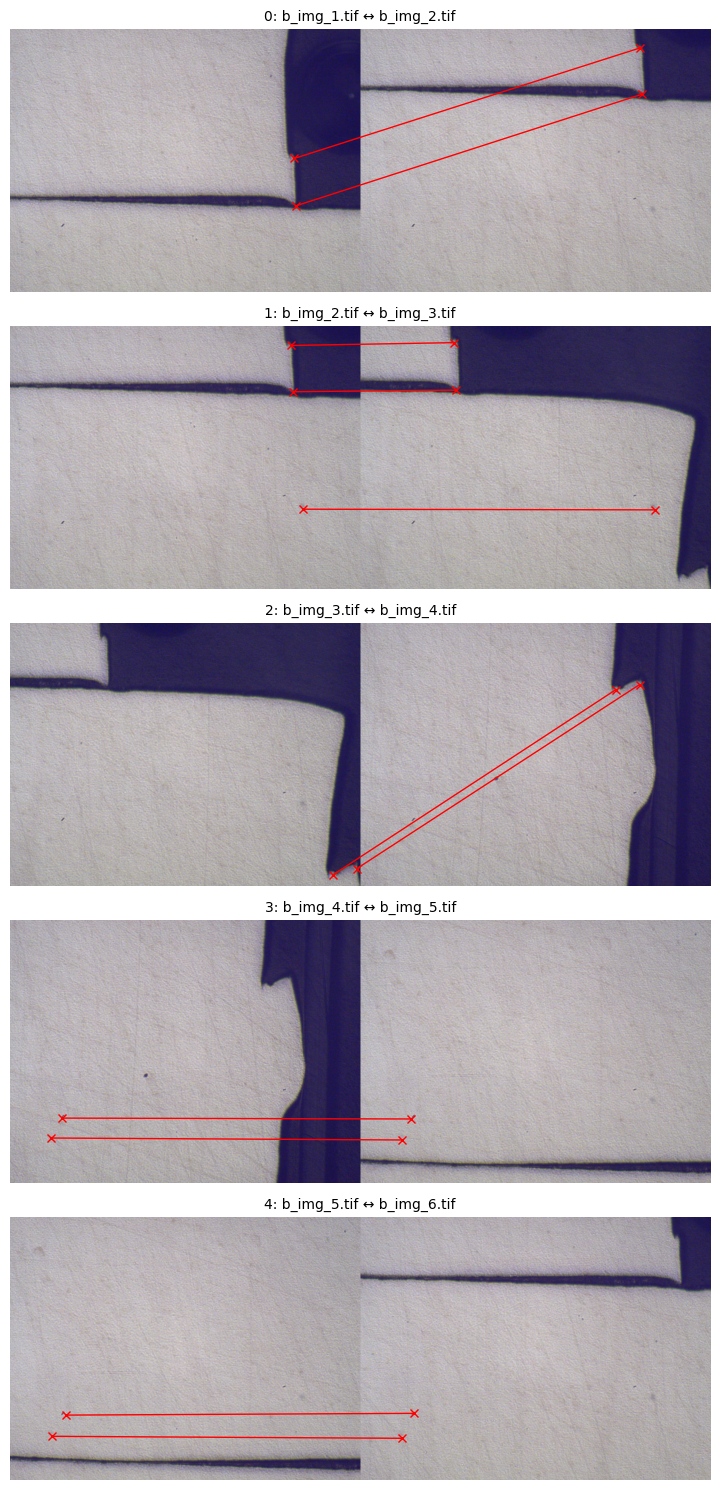

In [7]:
# 3) setting up plots 
fig, axes = plt.subplots(nrels, 1, figsize=(8, 3 * nrels), squeeze=False)
paths = mis.get_image_paths()

for idx, ((imgA, imgB), pts) in enumerate(unique_pt_rels):
    ax = axes[idx, 0]

    
    A = np.array(Image.open(paths[imgA]))
    B = np.array(Image.open(paths[imgB]))
    hA, wA = A.shape[:2]
    canvas = np.hstack([A, B])

    ax.imshow(canvas)
    ax.axis('off')
    ax.set_title(f"{idx}: {imgA} ↔ {imgB}", fontsize=10)

    
    for (x1,y1),(x2,y2) in pts:
        ax.plot([x1,   wA + x2],
                [y1,         y2],
                'rx-', linewidth=1)

plt.tight_layout()
plt.show()

In [8]:
#prv3: copy/modify/build from existing `render.ipynb` code to show unblended and blended renders for each image relation.
from sys import path as syspath
syspath.append("..")

from MISalign.model.mis_file import MisFile,load_mis
from MISalign.canvas.canvas_solve import rectangular_solve
import MISalign.canvas.canvas_render as cr


In [9]:
relations=mis_project.get_rels('r')
image_names=mis_project.get_image_names()
origin=image_names[0]
origin_relative_offsets=rectangular_solve(
    relations=relations,
    image_names=image_names,
    origin=origin
)
print("Origin-relative offsets")
display(origin_relative_offsets)
image_filepaths=mis_project.get_image_paths()
image_sizes=cr.find_image_sizes(image_filepaths)
origin_relative_extents=cr.find_relative_extents(
    image_names=image_names,
    origin_relative_offsets=origin_relative_offsets,
    image_sizes=image_sizes)
canvas_extents, canvas_offsets=cr.resolve_extents(origin_relative_extents)
canvas_relative_offsets=cr.place_in_canvas(
    image_names,
    origin_relative_offsets,
    canvas_extents,
    canvas_offsets)
print("Canvas-relative offsets")
display(canvas_relative_offsets)



Origin-relative offsets


{'b_img_1.tif': (0, 0),
 'b_img_2.tif': (-20, -507),
 'b_img_3.tif': (-588, -512),
 'b_img_4.tif': (-896, -1355),
 'b_img_5.tif': (-896, -1349),
 'b_img_6.tif': (-901, -1349)}

Canvas-relative offsets


{'b_img_1.tif': (0, 0),
 'b_img_2.tif': (20, 507),
 'b_img_3.tif': (588, 512),
 'b_img_4.tif': (896, 1355),
 'b_img_5.tif': (896, 1349),
 'b_img_6.tif': (901, 1349)}

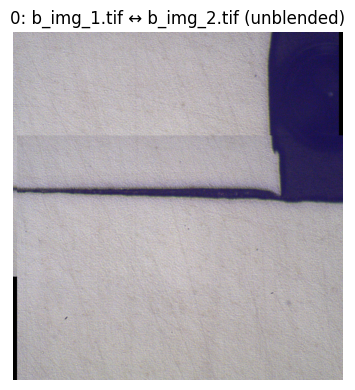

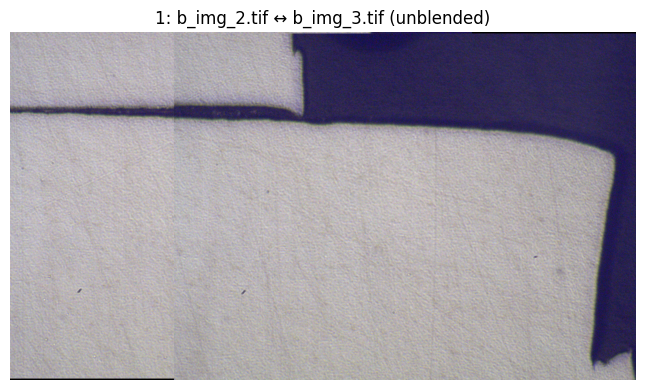

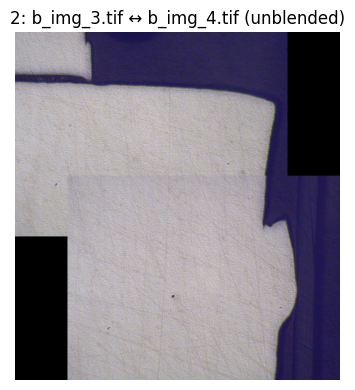

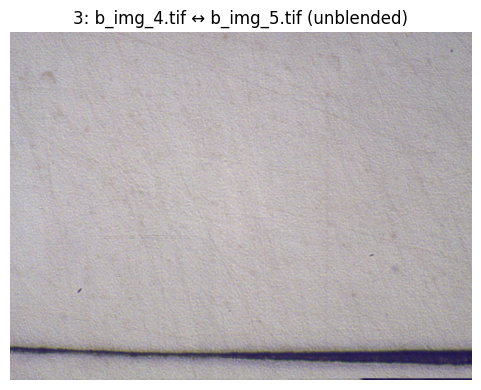

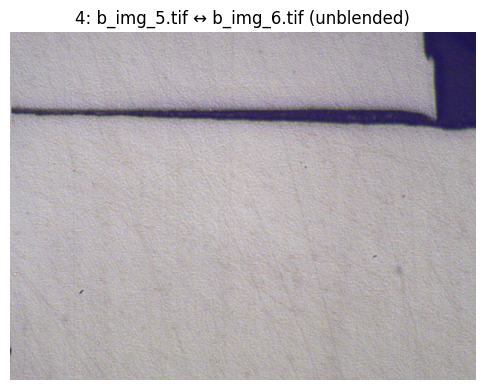

In [ ]:
#unblended renders
seen = set()
unique_pts = []
for (imgA, imgB), pts in relations_pts:
    if (imgA, imgB) not in seen:
        seen.add((imgA, imgB))
        unique_pts.append(((imgA, imgB), pts))

auto_save_renders = False

# 1) remove duplicates 
for i, ((imgA, imgB), pts) in enumerate(unique_pts):
    names = [imgA, imgB]

    # 2) render unblended image pais 
    full_canvas = cr.render_unblended(
        names,
        image_filepaths,
        image_sizes,
        canvas_relative_offsets,
        canvas_extents
    )

    # 4) produce image displays 
    bbox = full_canvas.getbbox()           
    tight_canvas = full_canvas.crop(bbox) if bbox else full_canvas

    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(np.array(tight_canvas))
    ax.axis('off')
    ax.set_title(f"{i}: {imgA} ↔ {imgB} (unblended)")
    plt.tight_layout()
    plt.show()

    if auto_save_renders:
        save_fp = mis_filepath.replace(".mis", f"-unblend-{i}.png")
        tight_canvas.save(save_fp)

    

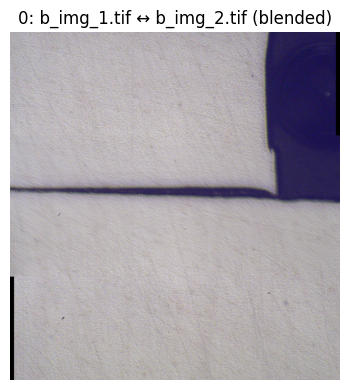

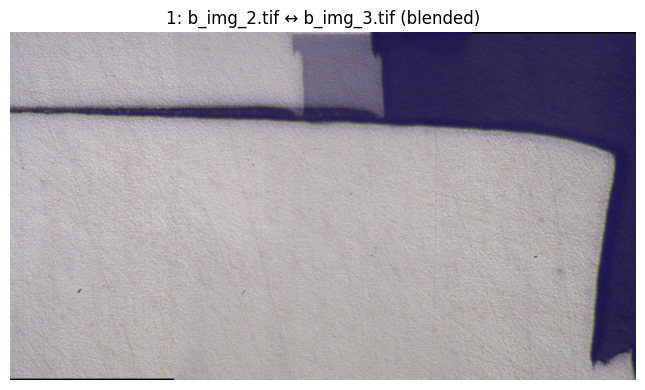

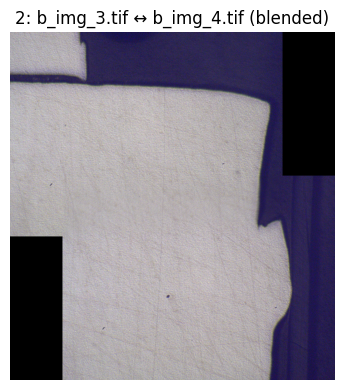

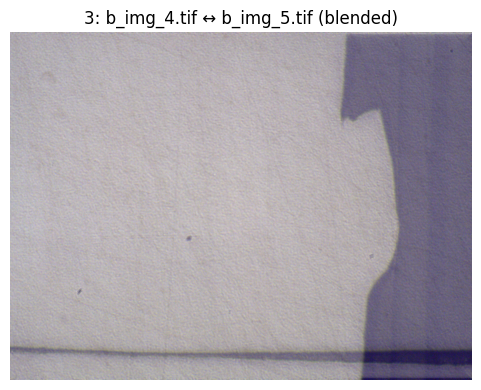

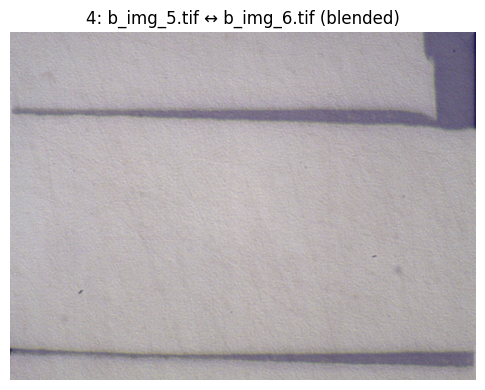

In [ ]:
#blended renders
seen = set()
unique_pts = []
for (imgA, imgB), pts in relations_pts:
    if (imgA, imgB) not in seen:
        seen.add((imgA, imgB))
        unique_pts.append(((imgA, imgB), pts))

auto_save_renders = False

# 1) remove duplicates 
for i, ((imgA, imgB), pts) in enumerate(unique_pts):
    image_names = [imgA, imgB]


    dfe_normalizer = cr.build_normalization(
        image_names,
        image_sizes,
        canvas_relative_offsets,
        canvas_extents,
        cr.weight_dfe
    )

    # 3) render image pairs 
    blended_canvas = cr.render_blended(
        image_names,
        image_paths,               
        image_sizes,
        canvas_relative_offsets,
        canvas_extents,
        cr.weight_dfe,
        dfe_normalizer
    )

    # 4) produce image displays 
    bbox      = blended_canvas.getbbox()      # (left,upper,right,lower) or None
    tight_bl  = blended_canvas.crop(bbox) if bbox else blended_canvas

    display the result
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(np.array(tight_bl))
    ax.axis('off')
    ax.set_title(f"{i}: {imgA} ↔ {imgB} (blended)")
    plt.tight_layout()
    plt.show()

    if auto_save_renders:
        out_fp = mis_filepath.replace(".mis", f"-blend-{i}.png")
        tight_bl.save(out_fp)


In [12]:
#prv4: Copy/modify/build from existing `feature_diff_grad_alignment` code to show difference of overlap region for each image relation.